In [1]:
import tensorflow as tf
import numpy as np
import os
from pathlib import Path

In [2]:
data_dir = Path(r"c:\Users\benke\Downloads\archive\Fruit And Vegetable Diseases Dataset")

print(data_dir.exists())
print(list(data_dir.iterdir())[:10])

True
[WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Banana__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Banana__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Bellpepper__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Bellpepper__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Carrot__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Carrot__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Cucumber__Healthy'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Cucumber__Rotten'), WindowsPath('c:/Users/benke/Downloads/archive/Fruit And Vegetable Disease

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Resizing,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

#Pfad zum Ordner (habe unterordner für nur äpflel erstellt)
data_dir = Path(r"c:/Users/benke/Downloads/archive/Fruit And Vegetable Diseases Dataset/Apple_Data")

img_size = (224, 224)
batch_size = 32
seed = 42

# 70 % Training 15 % val 15 % test
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="training",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

temp_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.3,
    subset="validation",
    seed=seed,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_ds.class_names

temp_batches = temp_ds.cardinality().numpy()
val_batches = temp_batches // 2
val_ds = temp_ds.take(val_batches)
test_ds = temp_ds.skip(val_batches)

print("Klassen:", class_names)
print("Training Batches:", train_ds.cardinality().numpy())
print("Validation Batches:", val_ds.cardinality().numpy())
print("Test Batches:", test_ds.cardinality().numpy())

Found 5363 files belonging to 2 classes.
Using 3755 files for training.
Found 5363 files belonging to 2 classes.
Using 1608 files for validation.
Klassen: ['Apple__Healthy', 'Apple__Rotten']
Training Batches: 118
Validation Batches: 25
Test Batches: 26


In [11]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Vortrainiertes CNN ohne letzte Klassifikationsschicht
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Gewichte zunächst einfrieren
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),

    # MobileNetV2 erwartet eine spezielle Vorverarbeitung
    layers.Lambda(preprocess_input),

    base_model,

    layers.GlobalAveragePooling2D(),
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.3),

    # 2 Klassen: Healthy / Rotten
    layers.Dense(2, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [7]:
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ModelCheckpoint
es = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

mc = ModelCheckpoint(
    filepath="bestTransferModel.keras",
    monitor="val_loss",
    save_best_only=True
)

In [12]:
mc=ModelCheckpoint(filepath='bestModel.keras',save_best_only=True)
model.fit(train_ds,validation_data=val_ds,epochs=10, callbacks=[es,mc])

Epoch 1/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 95s 753ms/step - accuracy: 0.9513 - loss: 0.1293 - val_accuracy: 0.9837 - val_loss: 0.0479
Epoch 2/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 88s 744ms/step - accuracy: 0.9840 - loss: 0.0417 - val_accuracy: 0.9862 - val_loss: 0.0421
Epoch 3/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 91s 771ms/step - accuracy: 0.9947 - loss: 0.0200 - val_accuracy: 0.9937 - val_loss: 0.0171
Epoch 4/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 88s 743ms/step - accuracy: 0.9979 - loss: 0.0118 - val_accuracy: 0.9925 - val_loss: 0.0212
Epoch 5/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 85s 721ms/step - accuracy: 0.9987 - loss: 0.0067 - val_accuracy: 0.9925 - val_loss: 0.0186
Epoch 6/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 83s 704ms/step - accuracy: 0.9968 - loss: 0.0082 - val_accuracy: 0.9962 - val_loss: 0.0139
Epoch 7/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 93s 792ms/step - accuracy: 0.9971 - loss: 0.0085 - val_accuracy: 0.9937 - val_loss: 0.0184
Epoch 8/10
118/118 ━━━━━━━━━━━━━━━━━━━━ 88s 737ms/step - accuracy: 0.9992 - loss: 0

In [13]:
model.load_weights('bestModel.keras')
score = model.evaluate(test_ds)

26/26 ━━━━━━━━━━━━━━━━━━━━ 17s 539ms/step - accuracy: 0.9963 - loss: 0.0193


In [14]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report

y_true = []
y_pred = []

for images, labels in test_ds:
    predictions = model.predict(images)
    predicted_labels = np.argmax(predictions, axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(predicted_labels)

print(confusion_matrix(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 743ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 587ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 591ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 595ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 579ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 574ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 573ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 602ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 742ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 771ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 669ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 611ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 575ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 600ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 577ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 560ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 604ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 603ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 

[[345   1]
 [  1 461]]


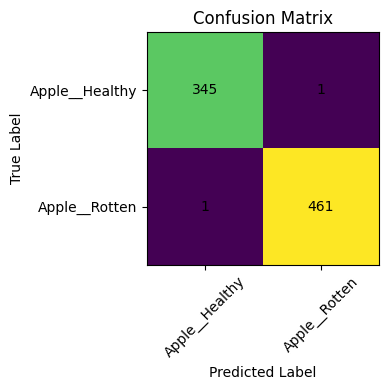

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print(cm)

plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
plt.yticks(np.arange(len(class_names)), class_names)

for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

In [ ]:
#!python -m pip install scikit-learn